## Многофакторная линейная регрессия

Источник данных: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

Набор данных о здоровье сна и образе жизни включает такие данные, как пол, возраст, профессия, продолжительность сна, качество сна, уровень физической активности, уровень стресса, категория ИМТ, артериальное давление, частота сердечных сокращений, количество шагов в день, а также наличие или отсутствие нарушений сна.

<details>
<summary>Описание признаков</summary>

| Признак | Описание |
|---------|----------|
| Person ID | An identifier for each individual |
| Gender | The gender of the person (Male/Female) |
| Age | The age of the person in years |
| Occupation | The occupation or profession of the person |
| Sleep Duration (hours) | The number of hours the person sleeps per day |
| Quality of Sleep (scale: 1-10) | A subjective rating of the quality of sleep, ranging from 1 to 10 |
| Physical Activity Level (minutes/day) | The number of minutes the person engages in physical activity daily |
| Stress Level (scale: 1-10) | A subjective rating of the stress level experienced by the person, ranging from 1 to 10 |
| BMI Category | The BMI category of the person (e.g., Underweight, Normal, Overweight) |
| Blood Pressure | The blood pressure measurement of the person, indicated as systolic pressure over diastolic pressure |
| Heart Rate (bpm) | The resting heart rate of the person in beats per minute |
| Daily Steps | The number of steps the person takes per day |
| Sleep Disorder | The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea) |

</details>

#### Цель: изучить зависимость продолжительности сна от субъективных и объективных показателей состояния здоровья человека.

#### Задача: построить многофакторную регрессионную модель, отражающую зависимость продолжительности сна от нескольких других показателей (пол, возраст, давление, чсс и т.д.).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

Исходные данные

In [3]:
data = pd.read_csv("data/sleep.csv")
data.sample(5)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
298,299,Female,51,Engineer,8.5,9,30,3,Normal,125/80,65,5000,NaN
335,336,Female,54,Engineer,8.4,9,30,3,Normal,125/80,65,5000,NaN
324,325,Female,53,Engineer,8.3,9,30,3,Normal,125/80,65,5000,NaN
284,285,Female,50,Nurse,6.0,6,90,8,Overweight,140/95,75,10000,Sleep Apnea
286,287,Female,50,Nurse,6.0,6,90,8,Overweight,140/95,75,10000,Sleep Apnea


Некоторые статистики по признакам:

In [4]:
data.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [5]:
data.describe(include=["O"])

C:\Users\temic\AppData\Local\Temp\ipykernel_12768\1126752233.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=["O"])


,Gender,Occupation,BMI Category,Blood Pressure,Sleep Disorder
count,374,374,374,374,155
unique,2,11,4,25,2
top,Male,Nurse,Normal,130/85,Sleep Apnea
freq,189,73,195,99,78


Пропущенные значения:

In [6]:
data.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Заменим пропущенные значения признака "Нарушение сна" числом 0, все остальные 1

Заменим значения пола на 0 (мужской пол) и 1 (женский)

Объединим значения BMI, отличные от нормального в одну категорию (1).

Удалим ID человека в датасете, потому что он совсем не влияет на длительность сна.

In [7]:
data["Sleep Disorder"] = (data["Sleep Disorder"].isna()).astype(int)
data["Gender"] = (data["Gender"] == "Female").astype(int)
data["BMI Category"] = (data["BMI Category"] != "Normal").astype(int)
data = data.drop(columns=["Person ID"])

### Приведение всех данных к стандартному виду

Категориальные признаки закодируем, признак "Blood Pressure" разделим на два признака -- верхнее и нижнее давление

In [8]:
def split_blood_pressure(df):
    df_copy = df.copy()

    split = df_copy["Blood Pressure"].str.split('/', expand=True)
    df_copy["Systolic"] = pd.to_numeric(split[0], errors="coerce")
    df_copy["Diastolic"] = pd.to_numeric(split[1], errors="coerce")
    df_copy = df_copy.drop('Blood Pressure', axis=1)
    
    return df_copy

In [9]:
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

numeric_features = data.select_dtypes(include="number").columns.tolist()
numeric_features.remove("Sleep Duration")
numeric_features.extend(["Systolic", "Diastolic"])
cat_features = data.select_dtypes(include="object").columns.drop("Blood Pressure").tolist()

pressure_tf = FunctionTransformer(split_blood_pressure)

pipeline = make_pipeline(
    pressure_tf,
    make_column_transformer(
        (MinMaxScaler(), numeric_features),
        (OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_features),
        verbose_feature_names_out=False,
        remainder="passthrough"
    )
)
data_transformed = pipeline.fit_transform(data)

C:\Users\temic\AppData\Local\Temp\ipykernel_12768\1092167817.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = data.select_dtypes(include="object").columns.drop("Blood Pressure").tolist()


Измененные данные (все значения от 0 до 1)

In [10]:
ct = pipeline.named_steps['columntransformer']
column_names = ct.get_feature_names_out()
df_transformed = pd.DataFrame(data_transformed, columns=column_names)
df_transformed.head(3)

,Gender,Age,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,...,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Sleep Duration
0,0.0,0.00000,0.4,0.2,0.6,1.0,0.571429,0.171429,1.0,0.407407,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.1
1,0.0,0.03125,0.4,0.5,1.0,0.0,0.476190,1.000000,1.0,0.370370,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.2
2,0.0,0.03125,0.4,0.5,1.0,0.0,0.476190,1.000000,1.0,0.370370,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.2


Разделение выборки на тренировочную и тестовую (20% значений идут в тест)

In [11]:
from sklearn.model_selection import train_test_split

y = df_transformed["Sleep Duration"]
X = df_transformed.drop(columns=["Sleep Duration"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Модель регрессии по МНК

In [28]:
import statsmodels.api as sm

X_train_with_const = sm.add_constant(X_train)
X_test_with_const = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train_with_const)

model_fitted = model.fit()
residuals = model_fitted.resid
y_train_pred = model_fitted.predict(X_train_with_const)
y_test_pred = model_fitted.predict(X_test_with_const)
model_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Sleep Duration   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     268.6
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          3.77e-107
Time:                        20:20:25   Log-Likelihood:                -92.257
No. Observations:                 299   AIC:                             196.5
Df Residuals:                     293   BIC:                             218.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       5.6470      0.093     60.911      0.000       5.464       5.829
Gender                     -0.1745      0.043     -4.089      0.000      -0.259      -0.091
Quality of Sleep            2.8115      0.094     29.959      0.000       2.627       2.996
Physical Activity Level     0.5872      0.098      5.999      0.000       0.395       0.780
Daily Steps                -0.8073      0.134     -6.041      0.000      -1.070      -0.544
Systolic                   -0.2755      0.076     -3.611      0.000      -0.426      -0.125
==============================================================================
Omnibus:                       17.572   Durbin-Watson:                   2.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               15.516
Skew:                           0.486   Prob(JB):                     0.000427
Kurtosis:                       2.451   Cond. No.                         15.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Проверка значимости коэффициентов:

p-value < 0.05 у таких признаков возраст, категория BMI, расстройство сна, пол, все субъективные и объективные показатели состояния здоровья (уровень стресса, давление и т.д.). Данные признаки значимы в контексте построенной модели.

p-value возраста, наличия расстройств сна, BMI, некоторых профессий (медсестра, учитель, менеджер, ученый) > 0.05, значит данные признаки не значимы.

Построим модель без учета незначимых признаков:

In [13]:
occupations = [col for col in df_transformed.columns if "Occupation" in col]
X = df_transformed.drop(columns=occupations + ["Age", "BMI Category", "Sleep Disorder", "Sleep Duration"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_with_const = sm.add_constant(X_train)

model2 = sm.OLS(y_train, X_train_with_const)
model2_fitted = model2.fit()
print("                     2 ШАГ")
model2_fitted.summary()

                     2 ШАГ


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Sleep Duration   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     190.1
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          1.42e-110
Time:                        19:38:52   Log-Likelihood:                -79.651
No. Observations:                 299   AIC:                             177.3
Df Residuals:                     290   BIC:                             210.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       5.7909      0.199     29.125      0.000       5.400       6.182
Gender                     -0.2426      0.047     -5.155      0.000      -0.335      -0.150
Quality of Sleep            2.7965      0.223     12.525      0.000       2.357       3.236
Physical Activity Level     0.4603      0.125      3.679      0.000       0.214       0.707
Stress Level               -0.1822      0.173     -1.050      0.295      -0.524       0.159
Heart Rate                  0.2122      0.179      1.183      0.238      -0.141       0.565
Daily Steps                -0.7605      0.194     -3.920      0.000      -1.142      -0.379
Systolic                   -1.2487      0.384     -3.250      0.001      -2.005      -0.493
Diastolic                   0.9441      0.380      2.486      0.013       0.197       1.691
==============================================================================
Omnibus:                       15.849   Durbin-Watson:                   2.128
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               15.364
Skew:                           0.505   Prob(JB):                     0.000461
Kurtosis:                       2.537   Cond. No.                         53.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

У модели, полученной на втором шаге опять появился незначимый признак -- частота пульса во сне.

Коэффициент детерминации стал хуже по сравнению с первой моделью ($R^2 = 0.84, R_{скорр}^2 = 0.836$)

Построим еще одну модель, но без учета частоты пульса:

In [14]:
occupations = [col for col in df_transformed.columns if "Occupation" in col]
X = df_transformed.drop(columns=occupations + ["Age", "BMI Category", "Sleep Disorder", "Sleep Duration", "Heart Rate"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_with_const = sm.add_constant(X_train)

model3 = sm.OLS(y_train, X_train_with_const)
model3_fitted = model3.fit()
print("                     3 ШАГ")
model3_fitted.summary()

                     3 ШАГ


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Sleep Duration   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     209.0
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          1.59e-109
Time:                        19:38:52   Log-Likelihood:                -84.559
No. Observations:                 299   AIC:                             185.1
Df Residuals:                     291   BIC:                             214.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       6.1253      0.193     31.744      0.000       5.746       6.505
Gender                     -0.2593      0.048     -5.407      0.000      -0.354      -0.165
Quality of Sleep            2.4712      0.219     11.297      0.000       2.041       2.902
Physical Activity Level     0.5590      0.104      5.394      0.000       0.355       0.763
Stress Level               -0.2573      0.156     -1.654      0.099      -0.563       0.049
Daily Steps                -0.9067      0.160     -5.659      0.000      -1.222      -0.591
Systolic                   -1.3320      0.401     -3.324      0.001      -2.121      -0.543
Diastolic                   1.0583      0.399      2.655      0.008       0.274       1.843
==============================================================================
Omnibus:                       23.199   Durbin-Watson:                   2.231
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               19.295
Skew:                           0.536   Prob(JB):                     6.46e-05
Kurtosis:                       2.368   Cond. No.                         53.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Незначимыми оказались низкое давление и уровень стресса.

Коэффициент детерминации стал еще немного хуже ($R^2 = 0.831, R_{скорр}^2 = 0.827$)

Построим еще одну модель, чтобы увидеть изменения:

In [15]:
occupations = [col for col in df_transformed.columns if "Occupation" in col]
X = df_transformed.drop(columns=occupations + ["Age", "BMI Category", "Sleep Disorder", "Sleep Duration", "Stress Level", "Diastolic", "Heart Rate"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_with_const = sm.add_constant(X_train)

model4 = sm.OLS(y_train, X_train_with_const)
model4_fitted = model4.fit()
print("                     4 ШАГ")
model4_fitted.summary()

                     4 ШАГ


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Sleep Duration   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     268.6
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          3.77e-107
Time:                        19:38:52   Log-Likelihood:                -92.257
No. Observations:                 299   AIC:                             196.5
Df Residuals:                     293   BIC:                             218.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       5.6470      0.093     60.911      0.000       5.464       5.829
Gender                     -0.1745      0.043     -4.089      0.000      -0.259      -0.091
Quality of Sleep            2.8115      0.094     29.959      0.000       2.627       2.996
Physical Activity Level     0.5872      0.098      5.999      0.000       0.395       0.780
Daily Steps                -0.8073      0.134     -6.041      0.000      -1.070      -0.544
Systolic                   -0.2755      0.076     -3.611      0.000      -0.426      -0.125
==============================================================================
Omnibus:                       17.572   Durbin-Watson:                   2.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               15.516
Skew:                           0.486   Prob(JB):                     0.000427
Kurtosis:                       2.451   Cond. No.                         15.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

На четвертом шаге осталось 5 признаков из исходных данных. Дальше будем рассматривать именно эту модель.

Общий вид:

$$ Продолжительность\_сна = -0.1533 \cdot Пол + 2.8716 \cdot Качество\_сна + 0.5566 \cdot Уровень\_активности \\
-0.7982 \cdot Количество\_шагов - 0.2669 \cdot Верхнее\_давление + 5.5951 $$

Свободный коэффициент 5.59 можно интерпретировать как базовую продолжительность сна (5ч 35мин), которая меняется в зависимости от приведенных факторов.

Наиболее сильное влияние на продолжительность сна оказывает субъективная оценка его качества от 1 до 10

Согласно полученным коэффициентам, при прочих равных женский пол связан с меньшей (на 9 минут) продолжительностью сна. При этом фактор пола наименее сильно влияет на продолжительность сна.

На первый взгляд связанные показатели оценки физической активности и количества пройденных шагов имеют коэффициенты с разными знаками.

**Проверяемые гипотезы**

- Для модели в целом:  
  `H0` — линейная связь между `Sleep Duration` и факторами состояния человека во сне отсутствует.  
  `H1` — линейная связь присутствует.

- Для свободного члена:  
  `H0` — свободный член равен 0.  
  `H1` — свободный член не равен 0.


In [63]:
def common_test(model4_fitted):
    is_regularized = not hasattr(model4_fitted, "rsquared")
    is_regularized = not hasattr(model4_fitted, "rsquared")
    
    y_pred = model4_fitted.predict(X_train_with_const)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    n = len(y)
    
    if not is_regularized:
        r2 = model4_fitted.rsquared
        r2_adj = model4_fitted.rsquared_adj
        sigma2 = model4_fitted.scale
    else:
        r2 = 1 - ss_res / ss_tot
        
        p_eff = np.sum(np.abs(model4_fitted.params) > 1e-10)
        
        df_resid = n - p_eff
        sigma2 = ss_res / df_resid if df_resid > 0 else np.nan
        r2_adj = 1 - (1 - r2) * (n - 1) / df_resid if df_resid > 0 else np.nan

    print(f"R^2 = {r2:.4f}")
    print(f"Adjusted R^2 = {r2_adj if r2_adj is not None else 0:.4f}")
    print(f"Остаточная дисперсия = {sigma2:.4f}")
    
    mean_approx_error = np.mean(np.abs((y - y_pred) / y)) * 100
    print(f"Средняя ошибка аппроксимации = {mean_approx_error:.2f}%")

    if not is_regularized:

        print(f"Остаточная дисперсия = {sigma2:.4f}")
        print(f"Средняя ошибка аппроксимации = {mean_approx_error:.2f}%")
        print()
        print(f"F-statistic p-value = {model4_fitted.f_pvalue:.4g}")
        print("p-value коэффициентов:")
        print(model4_fitted.pvalues)

        if model4_fitted.f_pvalue < 0.05:
            print("\nВывод по F-критерию: H0 отвергается, модель в целом статистически значима.")
        else:
            print("\nВывод по F-критерию: нет оснований отвергать H0, линейная связь не подтверждена.")

        if model4_fitted.pvalues["const"] < 0.05:
            print("Вывод по свободному члену: H0 отвергается, свободный член значим.")
        else:
            print("Вывод по свободному члену: нет оснований отвергать H0, свободный член незначим.")
common_test(model4_fitted)

R^2 = 0.8209
Adjusted R^2 = 0.8179
Остаточная дисперсия = 0.1107
Средняя ошибка аппроксимации = 3.66%
Остаточная дисперсия = 0.1107
Средняя ошибка аппроксимации = 3.66%

F-statistic p-value = 3.766e-107
p-value коэффициентов:
const                      2.135266e-168
Gender                      5.611041e-05
Quality of Sleep            3.380953e-91
Physical Activity Level     5.834865e-09
Daily Steps                 4.640063e-09
Systolic                    3.592894e-04
dtype: float64

Вывод по F-критерию: H0 отвергается, модель в целом статистически значима.
Вывод по свободному члену: H0 отвергается, свободный член значим.


**Проверка предпосылок**

- Для среднего остатка:  
  `H0` — математическое ожидание остатков равно 0.  
  `H1` — математическое ожидание остатков не равно 0.

- Для дисперсии остатков:  
  `H0` — остатки гомоскедастичны.  
  `H1` — остатки гетероскедастичны.

- Для автокорреляции:  
  `H0` — автокорреляция остатков отсутствует.  
  `H1` — автокорреляция остатков присутствует.

- Для нормальности:  
  `H0` — остатки распределены нормально.  
  `H1` — остатки не распределены нормально.


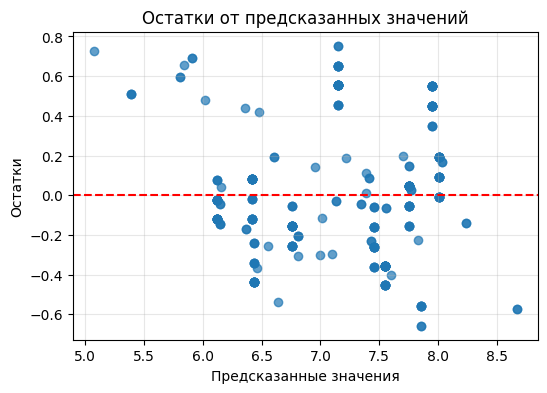

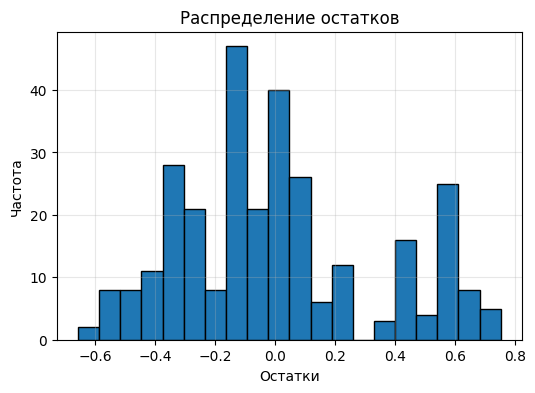

Среднее остатков = 0.000000
t_расч = 0.000000
t_табл = 1.967957
Вывод: H0 не отвергается, математическое ожидание остатков можно считать равным 0.

Breusch-Pagan p-value = 0.000000
Вывод: H0 отвергается, присутствует гетероскедастичность.

Durbin-Watson = 2.013891
Вывод: выраженной автокорреляции остатков не обнаружено.

Breusch-Godfrey = 1.530553
Вывод: выраженной автокорреляции остатков не обнаружено.

Shapiro-Wilk p-value = 1.06012e-08
Вывод: H0 отвергается, остатки не распределены нормально.



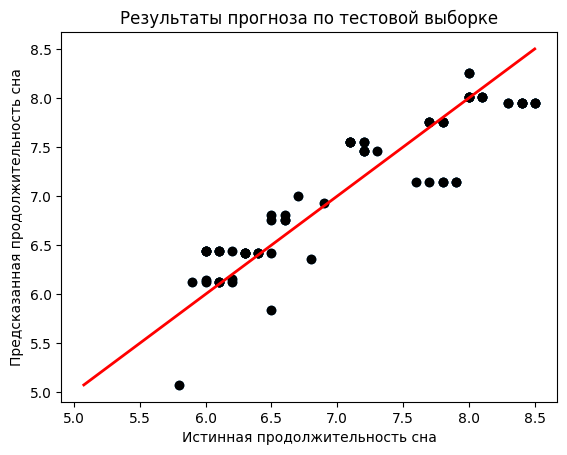

In [55]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey

def test_prerequisite(model4_fitted):
    plt.figure(figsize=(6, 4))
    plt.scatter(model4_fitted.fittedvalues, residuals, alpha=0.7)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Предсказанные значения")
    plt.ylabel("Остатки")
    plt.title("Остатки от предсказанных значений")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.hist(residuals, bins=20, edgecolor="black")
    plt.title("Распределение остатков")
    plt.xlabel("Остатки")
    plt.ylabel("Частота")
    plt.grid(True, alpha=0.3)
    plt.show()

    mean_res = residuals.mean()
    std_res = residuals.std(ddof=1)
    t_calc = mean_res / (std_res / np.sqrt(len(residuals)))
    t_crit = stats.t.ppf(1 - 0.05 / 2, len(residuals) - 1)

    bp_lm, bp_pvalue, bp_fvalue, bp_fpvalue = het_breuschpagan(residuals, model4_fitted.model.exog)
    
    is_regularized = not hasattr(model4_fitted, "rsquared")
    if not is_regularized:
        lm_stat, p_val, f_stat, f_p_val = acorr_breusch_godfrey(model4_fitted, nlags=2)
    else:
        lm_stat, p_val = None, None
    dw_stat = durbin_watson(residuals)
    shapiro_stat, shapiro_pvalue = stats.shapiro(residuals)

    print(f"Среднее остатков = {mean_res:.6f}")
    print(f"t_расч = {t_calc:.6f}")
    print(f"t_табл = {t_crit:.6f}")
    if abs(t_calc) < t_crit:
        print("Вывод: H0 не отвергается, математическое ожидание остатков можно считать равным 0.")
    else:
        print("Вывод: H0 отвергается, математическое ожидание остатков отлично от 0.")

    print()
    print(f"Breusch-Pagan p-value = {bp_pvalue:.6f}")
    if bp_pvalue < 0.05:
        print("Вывод: H0 отвергается, присутствует гетероскедастичность.")
    else:
        print("Вывод: нет оснований отвергать H0, явных признаков гетероскедастичности нет.")

    print()
    print(f"Durbin-Watson = {dw_stat:.6f}")
    if dw_stat < 1.5:
        print("Вывод: наблюдается положительная автокорреляция остатков.")
    elif dw_stat > 2.5:
        print("Вывод: наблюдается отрицательная автокорреляция остатков.")
    else:
        print("Вывод: выраженной автокорреляции остатков не обнаружено.")

    if p_val is not None:
        print()
        print(f"Breusch-Godfrey = {lm_stat:.6f}")
        if p_val < 0.05:
            print("Вывод: наблюдается автокорреляция остатков.")  
        else:
            print("Вывод: выраженной автокорреляции остатков не обнаружено.")
    print()

    print(f"Shapiro-Wilk p-value = {shapiro_pvalue:.6g}")
    if shapiro_pvalue < 0.05:
        print("Вывод: H0 отвергается, остатки не распределены нормально.")
    else:
        print("Вывод: нет оснований отвергать H0, нормальность остатков не нарушена.")
    
    print()
    X_test_with_const = sm.add_constant(X_test)
    y_pred = model4_fitted.predict(X_test_with_const)
    plt.scatter(y_test, y_pred)

    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    plt.scatter(y_test, y_pred, c="black")
    plt.plot([mn, mx], [mn, mx], c="red", lw="2.")
    plt.xlabel("Истинная продолжительность сна")
    plt.ylabel("Предсказанная продолжительность сна")
    plt.title("Результаты прогноза по тестовой выборке")

test_prerequisite(model4_fitted)

### Ridge-регрессия

In [69]:
model_ridge = sm.OLS(y_train, X_train_with_const)
model_ridge = model_ridge.fit_regularized(L1_wt=0, alpha=0.03)
print("                     Ridge-регрессия")
pd.DataFrame({"Признак": ["const"] + list(X_train.columns), "Коэффициент": model_ridge.params})

                     Ridge-регрессия


,Признак,Коэффициент
0,const,4.467335
1,Gender,-0.026143
2,Quality of Sleep,2.920672
3,Physical Activity Level,0.244368
4,Daily Steps,0.546374
5,Systolic,0.376683


Уравнение идентично полученному ранее уравнению без L2-регуляризации

$$ Продолжительность\_сна = -0.02 \cdot Пол + 2.92 \cdot Качество\_сна + 0.244 \cdot Уровень\_активности \\
+ 0.54 \cdot Количество\_шагов + 0.376 \cdot Верхнее\_давление + 4.46 $$

Свободный коэффициент, который раньше интерпретировался как базовая продолжительность сна, уменьшился.

Признак Пол почти не вносит вклад в продолжительность сна.

Поменялся знак у коэффициента при признаке Количество шагов.

Наиболее сильный вклад в продолжительность сна по-прежнуму вносит его качество.

**Проверяемые гипотезы**

- Для модели в целом:  
  `H0` — линейная связь между `Sleep Duration` и факторами состояния человека во сне отсутствует.  
  `H1` — линейная связь присутствует.

- Для свободного члена:  
  `H0` — свободный член равен 0.  
  `H1` — свободный член не равен 0.


In [70]:
common_test(model_ridge)

R^2 = 0.7086
Adjusted R^2 = 0.7046
Остаточная дисперсия = 0.1870
Средняя ошибка аппроксимации = 5.01%


**Проверка предпосылок**

- Для среднего остатка:  
  `H0` — математическое ожидание остатков равно 0.  
  `H1` — математическое ожидание остатков не равно 0.

- Для дисперсии остатков:  
  `H0` — остатки гомоскедастичны.  
  `H1` — остатки гетероскедастичны.

- Для автокорреляции:  
  `H0` — автокорреляция остатков отсутствует.  
  `H1` — автокорреляция остатков присутствует.

- Для нормальности:  
  `H0` — остатки распределены нормально.  
  `H1` — остатки не распределены нормально.


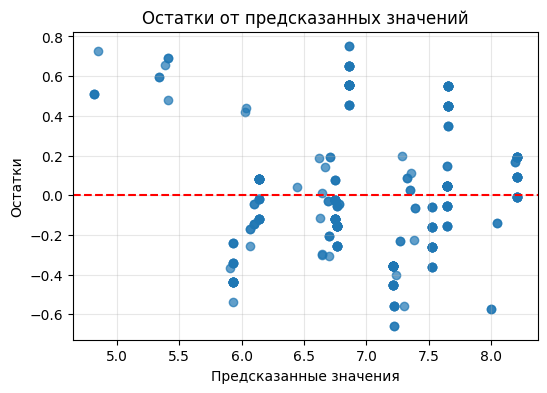

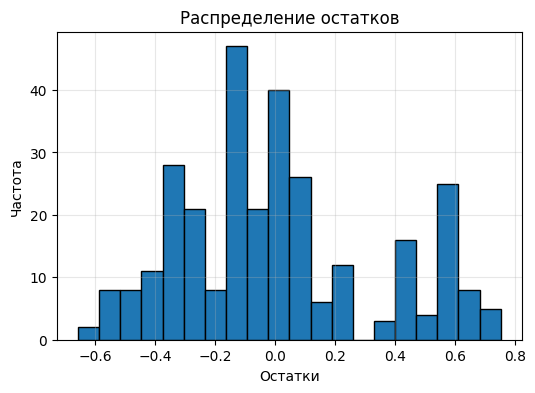

Среднее остатков = 0.000000
t_расч = 0.000000
t_табл = 1.967957
Вывод: H0 не отвергается, математическое ожидание остатков можно считать равным 0.

Breusch-Pagan p-value = 0.000000
Вывод: H0 отвергается, присутствует гетероскедастичность.

Durbin-Watson = 2.013891
Вывод: выраженной автокорреляции остатков не обнаружено.

Shapiro-Wilk p-value = 1.06012e-08
Вывод: H0 отвергается, остатки не распределены нормально.



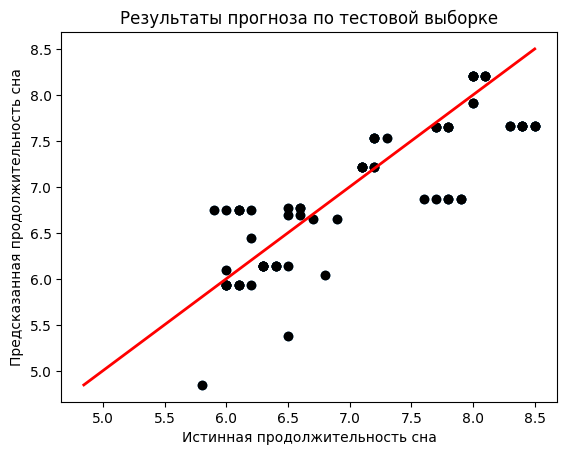

In [71]:
test_prerequisite(model_ridge)

### LASSO-регрессия

In [74]:
model_lasso = sm.OLS(y_train, X_train_with_const)
model_lasso = model_lasso.fit_regularized(L1_wt=1, alpha=0.01)
print("                     LASSO-регрессия")
pd.DataFrame({"Признак": ["const"] + list(X_train.columns), "Коэффициент": model_lasso.params})

                     LASSO-регрессия


,Признак,Коэффициент
const,const,5.412712
Gender,Gender,0.000000
Quality of Sleep,Quality of Sleep,2.712024
Physical Activity Level,Physical Activity Level,0.242450
Daily Steps,Daily Steps,-0.219422
Systolic,Systolic,-0.151481


Уравнение идентично предыдущим моделям.

$$ Продолжительность\_сна = 2.71 \cdot Качество\_сна + 0.24 \cdot Уровень\_активности \\
-0.22 \cdot Количество\_шагов - 0.151 \cdot Верхнее\_давление + 5.41 $$

Свободный коэффициент почти не изменился по сравнению с моделью без регуляризации.

Признак Пол получил нулевой коэффициент -- модель отсеяла его как незначимый.

Все признаки, кроме качества сна вносят небольшой вклад в продолжительность сна.

**Проверяемые гипотезы**

- Для модели в целом:  
  `H0` — линейная связь между `Sleep Duration` и факторами состояния человека во сне отсутствует.  
  `H1` — линейная связь присутствует.

- Для свободного члена:  
  `H0` — свободный член равен 0.  
  `H1` — свободный член не равен 0.


In [76]:
common_test(model_lasso)

R^2 = 0.8388
Adjusted R^2 = 0.8371
Остаточная дисперсия = 0.1031
Средняя ошибка аппроксимации = 4.27%


**Проверка предпосылок**

- Для среднего остатка:  
  `H0` — математическое ожидание остатков равно 0.  
  `H1` — математическое ожидание остатков не равно 0.

- Для дисперсии остатков:  
  `H0` — остатки гомоскедастичны.  
  `H1` — остатки гетероскедастичны.

- Для автокорреляции:  
  `H0` — автокорреляция остатков отсутствует.  
  `H1` — автокорреляция остатков присутствует.

- Для нормальности:  
  `H0` — остатки распределены нормально.  
  `H1` — остатки не распределены нормально.


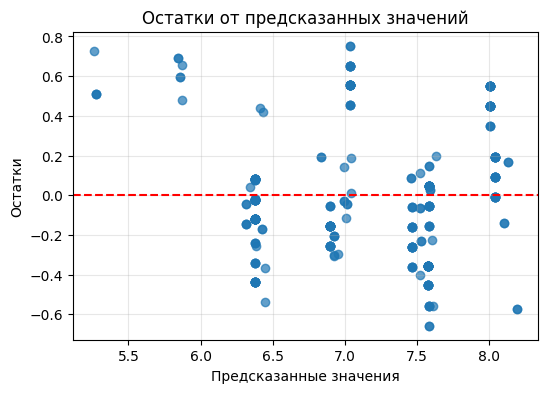

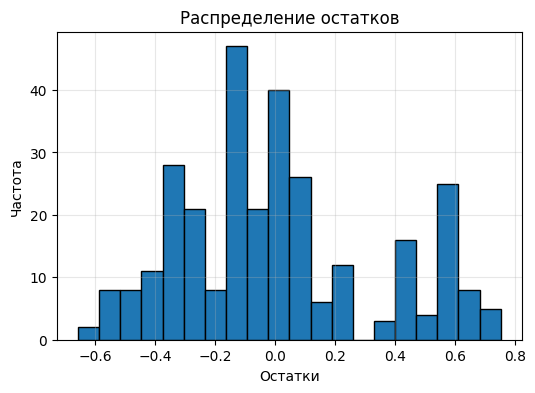

Среднее остатков = 0.000000
t_расч = 0.000000
t_табл = 1.967957
Вывод: H0 не отвергается, математическое ожидание остатков можно считать равным 0.

Breusch-Pagan p-value = 0.000000
Вывод: H0 отвергается, присутствует гетероскедастичность.

Durbin-Watson = 2.013891
Вывод: выраженной автокорреляции остатков не обнаружено.

Shapiro-Wilk p-value = 1.06012e-08
Вывод: H0 отвергается, остатки не распределены нормально.



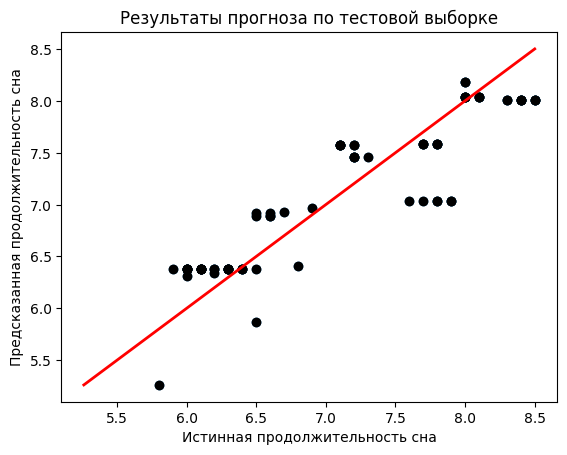

In [77]:
test_prerequisite(model_lasso)

Сравнение моделей линейной регрессии по MAPE, RMSE, MAE

In [78]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, root_mean_squared_error

def evaluate_model(model, name):
    
    prediction = model.predict(sm.add_constant(X_test))
    print(f"""
        {name}
        MAPE: {mean_absolute_percentage_error(y_test, prediction)}
        RMSE: {root_mean_squared_error(y_test, prediction)}
        MAE: {mean_absolute_error(y_test, prediction)}""")

for mod, name in zip([model4_fitted, model_ridge, model_lasso],
                     ["Обычный МНК", "Ridge", "Lasso"]):
    evaluate_model(mod, name)



        Обычный МНК
        MAPE: 0.037838966456906944
        RMSE: 0.3418220181712761
        MAE: 0.2693188876670383

        Ridge
        MAPE: 0.05104368005390667
        RMSE: 0.4839775477236957
        MAE: 0.3648892167693079

        Lasso
        MAPE: 0.04242127555362642
        RMSE: 0.361322180100371
        MAE: 0.29975434684200586


Ошибки предсказаний составляют от 16 до 29 минут.

Наиболее точной оказалась модель без регуляризации -- по каждой метрике она лучше других моделей на значения порядка $10^-2$

Средняя ошибка обычной МНК модели равна 3.78%

### Вывод:

В процессе пошагового отбора признаков была получена итоговая модель множественной линейной регрессии, обладающая достаточно высоким качеством аппроксимации (R^2 = 0.83). При этом часть исходных признаков оказалась статистически незначимой и была исключена, что позволило упростить модель без существенной потери качества.

Качество моделей с регуляризацией не превышало качество обычной модели МНК. Это может быть связано с тем, что в данных отсутствует сильная мультиколлинеарность и применение регуляризации не дает прибавки в точности.

Сравнение моделей по метрикам MAPE, MAE, RMSE показало, что все модели дают близкие результаты на тестовой выборке, а средняя ошибка прогнозов говорит о приемлемой точности моделей в контексте задачи предсказания продолжительности сна.